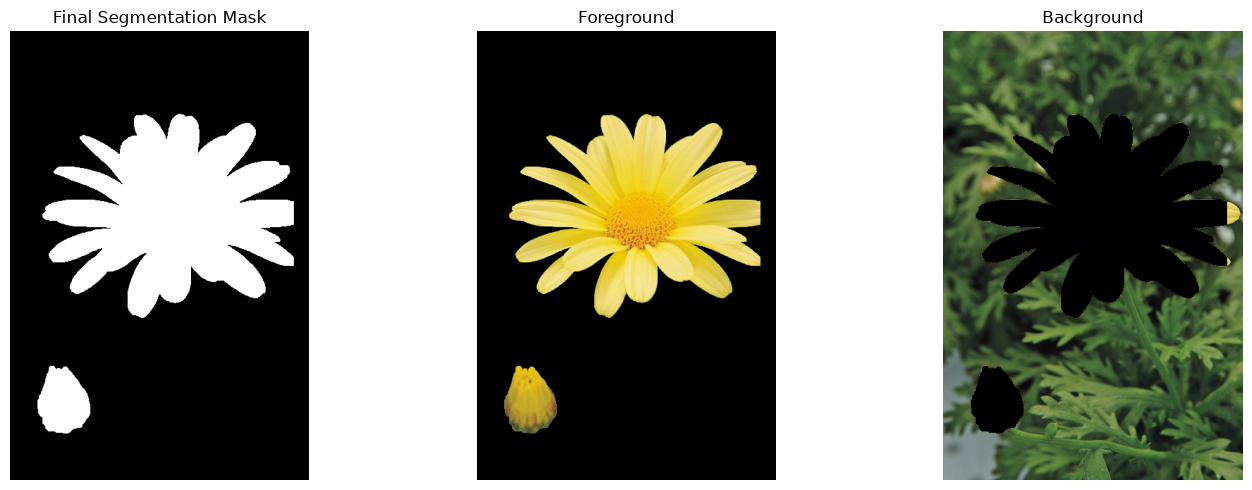

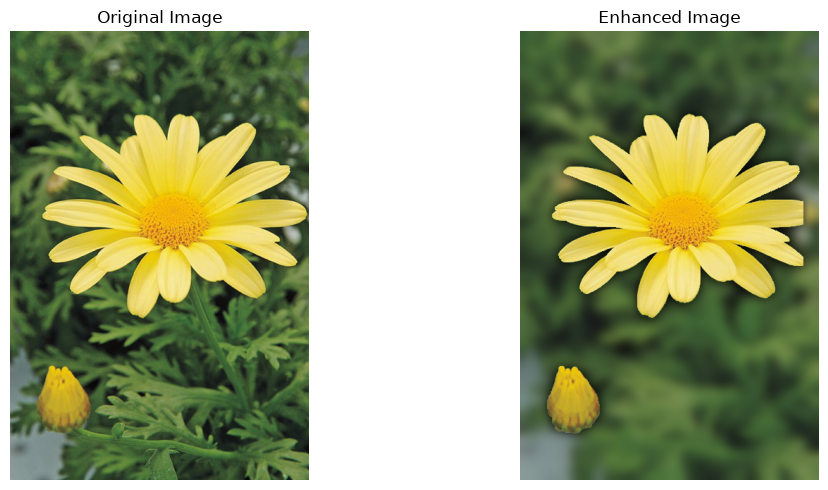

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


image = cv.imread(
    r'D:\Image processing and Computer Vision\Images\sunflower.png'
)

assert image is not None

image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

height, width = image.shape[:2]

mask = np.zeros((height, width), np.uint8)

rect = (
    int(width * 0.05),
    int(height * 0.05),
    int(width * 0.90),
    int(height * 0.90)
)

background_model = np.zeros((1, 65), np.float64)
foreground_model = np.zeros((1, 65), np.float64)

cv.grabCut(
    image,
    mask,
    rect,
    background_model,
    foreground_model,
    5,
    cv.GC_INIT_WITH_RECT
)

segmentation_mask = np.where(
    (mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD),
    1,
    0
).astype(np.uint8)


foreground = (
    image_rgb *
    segmentation_mask[:, :, np.newaxis]
).astype(np.uint8)

background = (
    image_rgb *
    (1 - segmentation_mask[:, :, np.newaxis])
).astype(np.uint8)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(segmentation_mask, cmap="gray")
plt.title("Final Segmentation Mask")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(foreground)
plt.title("Foreground")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(background)
plt.title("Background")
plt.axis("off")

plt.tight_layout()
plt.show()


background_bgr = cv.cvtColor(
    background,
    cv.COLOR_RGB2BGR
)

blurred_background = cv.GaussianBlur(
    background_bgr,
    (51, 51),
    0
)

blurred_background = cv.cvtColor(
    blurred_background,
    cv.COLOR_BGR2RGB
)


enhanced_image = (
    foreground +
    blurred_background *
    (1 - segmentation_mask[:, :, np.newaxis])
).astype(np.uint8)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced_image)
plt.title("Enhanced Image")
plt.axis("off")

plt.tight_layout()
plt.show()

This happens because GrabCut does not produce a perfectly accurate boundary. Pixels close to the flower can be incorrectly classified as foreground/background. When the extracted background is blurred and combined with the foreground, those incorrectly classified dark pixels around the flower boundary become visible.